In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Loading the data 
ratings = pd.read_csv('ml-100k/ml-100k/u.data',sep='\t',names=['userId','movieId','rating','timestamp'])
movies = pd.read_csv('ml-100k/ml-100k/u.item', sep='|', encoding='latin-1',
                      names=['movieId', 'title'] + [f'col_{i}' for i in range(22)],
                      usecols=['movieId', 'title'])
print("Ratings shape:",ratings.shape)
print("Movies shape:",movies.shape)
print()
print(ratings.head(10))
print()
print(movies.head())
print()
print(ratings.info)
print(movies.info)



Ratings shape: (100000, 4)
Movies shape: (1682, 2)

   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596
5     298      474       4  884182806
6     115      265       2  881171488
7     253      465       5  891628467
8     305      451       3  886324817
9       6       86       3  883603013

   movieId              title
0        1   Toy Story (1995)
1        2   GoldenEye (1995)
2        3  Four Rooms (1995)
3        4  Get Shorty (1995)
4        5     Copycat (1995)

<bound method DataFrame.info of        userId  movieId  rating  timestamp
0         196      242       3  881250949
1         186      302       3  891717742
2          22      377       1  878887116
3         244       51       2  880606923
4         166      346       1  886397596
...       ...      ...     ...        ...
99995     880      476

In [22]:
rating_count = ratings.groupby('movieId')['rating'].count()
print("Rating count\n",rating_count)
print()
print("Most rated movie id is :",rating_count.idxmax(),"with",rating_count.max(),"times rated")
print()
print("Least rated movie id is :",rating_count.idxmin(),"with",rating_count.min(),"times rated")

Rating count
 movieId
1       452
2       131
3        90
4       209
5        86
       ... 
1678      1
1679      1
1680      1
1681      1
1682      1
Name: rating, Length: 1682, dtype: int64

Most rated movie id is : 50 with 583 times rated

Least rated movie id is : 599 with 1 times rated


In [28]:
avg_rating = ratings.groupby('movieId')['rating'].mean()
print(avg_rating)

movieId
1       3.878319
2       3.206107
3       3.033333
4       3.550239
5       3.302326
          ...   
1678    1.000000
1679    3.000000
1680    2.000000
1681    3.000000
1682    3.000000
Name: rating, Length: 1682, dtype: float64


In [32]:
movie_stats = pd.DataFrame({
    "rating" : avg_rating,
    "count" : rating_count
}).join(movies.set_index('movieId')['title'])
print(movie_stats)

           rating  count                                      title
movieId                                                            
1        3.878319    452                           Toy Story (1995)
2        3.206107    131                           GoldenEye (1995)
3        3.033333     90                          Four Rooms (1995)
4        3.550239    209                          Get Shorty (1995)
5        3.302326     86                             Copycat (1995)
...           ...    ...                                        ...
1678     1.000000      1                          Mat' i syn (1997)
1679     3.000000      1                           B. Monkey (1998)
1680     2.000000      1                       Sliding Doors (1998)
1681     3.000000      1                        You So Crazy (1994)
1682     3.000000      1  Scream of Stone (Schrei aus Stein) (1991)

[1682 rows x 3 columns]


In [44]:
print("Top 20 most rated movies with their average count and rating :")
print()
print(movie_stats.nlargest(20,'count'))

Top 20 most rated movies with their average count and rating :

           rating  count                             title
movieId                                                   
50       4.358491    583                  Star Wars (1977)
258      3.803536    509                    Contact (1997)
100      4.155512    508                      Fargo (1996)
181      4.007890    507         Return of the Jedi (1983)
294      3.156701    485                  Liar Liar (1997)
286      3.656965    481       English Patient, The (1996)
288      3.441423    478                     Scream (1996)
1        3.878319    452                  Toy Story (1995)
300      3.631090    431              Air Force One (1997)
121      3.438228    429     Independence Day (ID4) (1996)
174      4.252381    420    Raiders of the Lost Ark (1981)
127      4.283293    413             Godfather, The (1972)
56       4.060914    394               Pulp Fiction (1994)
7        3.798469    392             Twelve Monkeys

In [50]:
#Removing the movie containing movies rated 1 time
#movie_stats = movie_stats[movie_stats['count'] != 1]
print((movie_stats['count']== 1).sum())

141


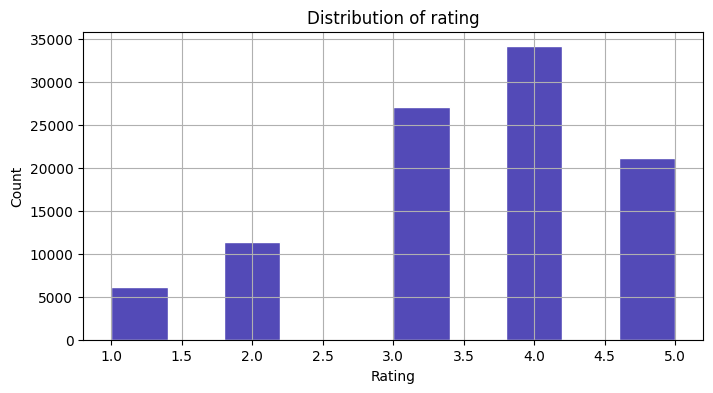

In [54]:
# Plot rating distribution
plt.figure(figsize=(8,4))
ratings['rating'].hist(bins=10,color='#534AB7',edgecolor='white')
plt.title('Distribution of rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [55]:
#Users are generous raters .The most common rating is 4 out of 5 (~34,000 times). People rarely give 1s. This means your dataset is positively skewed — most ratings cluster between 3 and 5